In [ ]:
# Importing the libraries 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")


In [ ]:
# reading the dataset
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.shape

(1200, 14)

In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [7]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [ ]:
# 1. Convert dates and derive time-based features

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['order_year'] = df['Date'].dt.year
df['order_month'] = df['Date'].dt.month
df['order_dayofweek'] = df['Date'].dt.dayofweek

# 2. Handle missing data
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')
df['discount_flag'] = np.where(df['CouponCode'] == 'NO_COUPON', 0, 1)

numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
print('Numeric missing values before imputation:')
print(df[numeric_cols].isna().sum())

# Median imputation for numeric features
median_values = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(median_values)

# KNN imputation as a second option for numeric features
knn_imputer = KNNImputer(n_neighbors=3)
df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])

# 3. Feature engineering

df['price_per_item'] = df['TotalPrice'] / df['Quantity']
df['cart_fill_ratio'] = df['Quantity'] / df['ItemsInCart'].replace(0, np.nan)
df['cart_fill_ratio'] = df['cart_fill_ratio'].fillna(0)
df['is_high_value_order'] = (df['TotalPrice'] > df['TotalPrice'].median()).astype(int)

df['referral_feature'] = df['ReferralSource'].map({
    'Instagram': 1,
    'Facebook': 1,
    'Google': 1,
    'Email': 0,
    'Referral': 1,
    'Other': 0
}).fillna(0).astype(int)

# 4. Outlier detection and neutralization
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[f'{col}_is_outlier'] = ((df[col] < lower) | (df[col] > upper)).astype(int)
    df[col] = df[col].clip(lower, upper)

# Z-score outlier summary for TotalPrice and Quantity
zscore_outliers = (np.abs(zscore(df['TotalPrice'])) > 3) | (np.abs(zscore(df['Quantity'])) > 3)
print(f'Z-score outliers detected: {zscore_outliers.sum()}')

# 5. Final dataset review
print('\nNew engineered features:')
print(df[['price_per_item', 'cart_fill_ratio', 'discount_flag', 'is_high_value_order', 'referral_feature']].head())
print('\nOutlier counts:')
print(df[[f'{col}_is_outlier' for col in numeric_cols]].sum())



Numeric missing values before imputation:
Quantity       0
UnitPrice      0
ItemsInCart    0
TotalPrice     0
dtype: int64
Z-score outliers detected: 0

New engineered features:
   price_per_item  cart_fill_ratio  discount_flag  is_high_value_order  \
0          570.62         0.714286              1                    1   
1          151.35         0.666667              1                    0   
2          550.68         0.625000              1                    1   
3          273.19         0.200000              1                    0   
4          626.01         0.500000              1                    1   

   referral_feature  
0                 1  
1                 1  
2                 0  
3                 1  
4                 0  

Outlier counts:
Quantity_is_outlier       0
UnitPrice_is_outlier      0
ItemsInCart_is_outlier    0
TotalPrice_is_outlier     8
dtype: int64


<Figure size 1200x600 with 0 Axes>

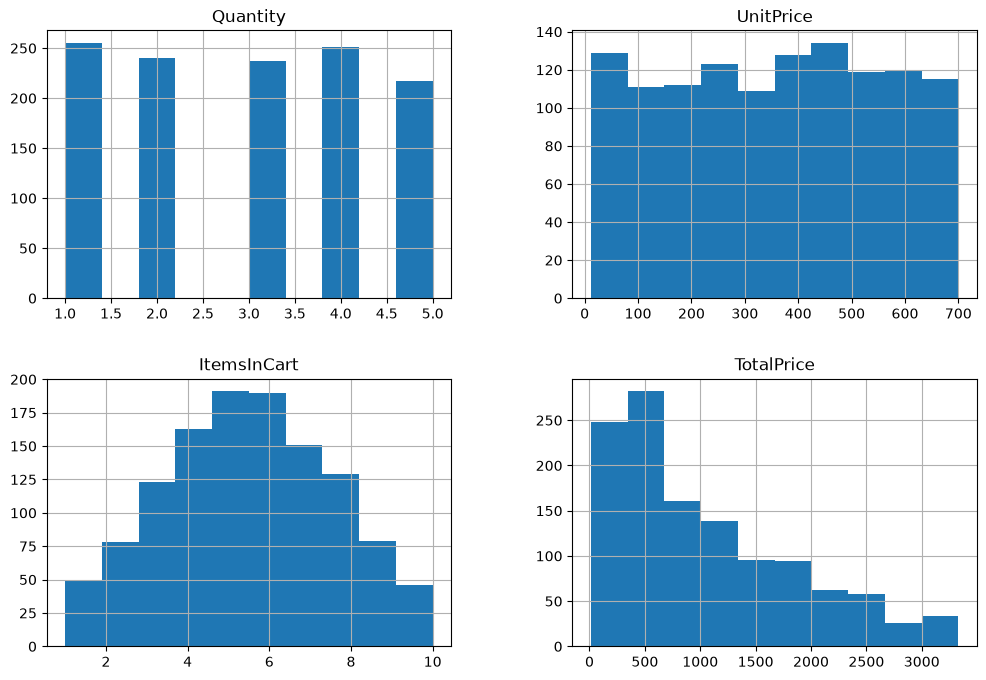

In [ ]:
# distribution of numeric features
plt.figure(figsize=(12,6))

df[numeric_cols].hist(
    figsize=(12,8)
)

plt.show()

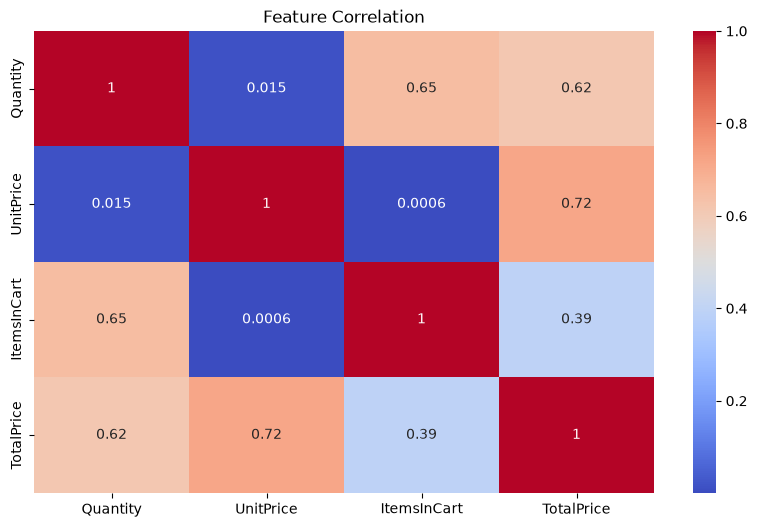

In [ ]:
#heatmap of correlation between numeric features
plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [11]:
df.to_csv(
    "project_1_cleaned_dataset.csv",
    index=False
)